# Synthetic Customer & Transaction Data — Method Comparison

Compares four synthesis strategies on the same seed data:

| # | Method | Synthesizer | Key property |
|---|---|---|---|
| 1 | **HMA + Gaussian Copula** | SDV default multi-table | Native FK integrity + cardinality |
| 2 | **Independent CTGAN** | CTGANSynthesizer per table | Better within-table distributions |
| 3 | **CTGAN + PAR Hybrid** | CTGAN (customers) + PAR (transactions) | Temporal realism + cross-table context |
| 4 | **Independent TVAE** | TVAESynthesizer per table | VAE: smooth marginals, stable training |

**Evaluation axes**
- Standard SDMetrics: Column Shapes, Column Pair Trends, Diagnostic
- **Cross-table correlation** (custom): Spearman(income → % investment products) — preserved?
- **Temporal realism** (custom): inter-arrival time KS test + amount autocorrelation

In [1]:
import sys, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR    = Path('data')
REPORTS_DIR = Path('reports')
DATA_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
METHOD_COLORS = {
    'M1 – HMA GC':    '#4e79a7',
    'M2 – CTGAN':     '#f28e2b',
    'M3 – CTGAN+PAR': '#59a14f',
    'M4 – TVAE':      '#e15759',
    'Real':           '#bab0ac',
}
print('Ready.')

Ready.


---
## 1  Seed Data

500 customers with business-rule-driven demographics and transaction histories.  
This is the **real** dataset all three synthesizers learn from.

In [2]:
from src.seed_data import make_seed_data

real_data = make_seed_data(n_customers=1000)
for name, df in real_data.items():
    df.to_csv(DATA_DIR / f'real_{name}.csv', index=False)

real_2t = {k: real_data[k] for k in ('customers', 'transactions')}
df_c = real_data['customers']
df_t = real_data['transactions']

print(f'customers    : {len(df_c):,} rows')
print(f'transactions : {len(df_t):,} rows  (avg {len(df_t)/len(df_c):.1f} per customer)')
print(f'products     : {len(real_data["products"]):,} rows  (static catalog)')

customers    : 1,000 rows
transactions : 3,999 rows  (avg 4.0 per customer)
products     : 15 rows  (static catalog)


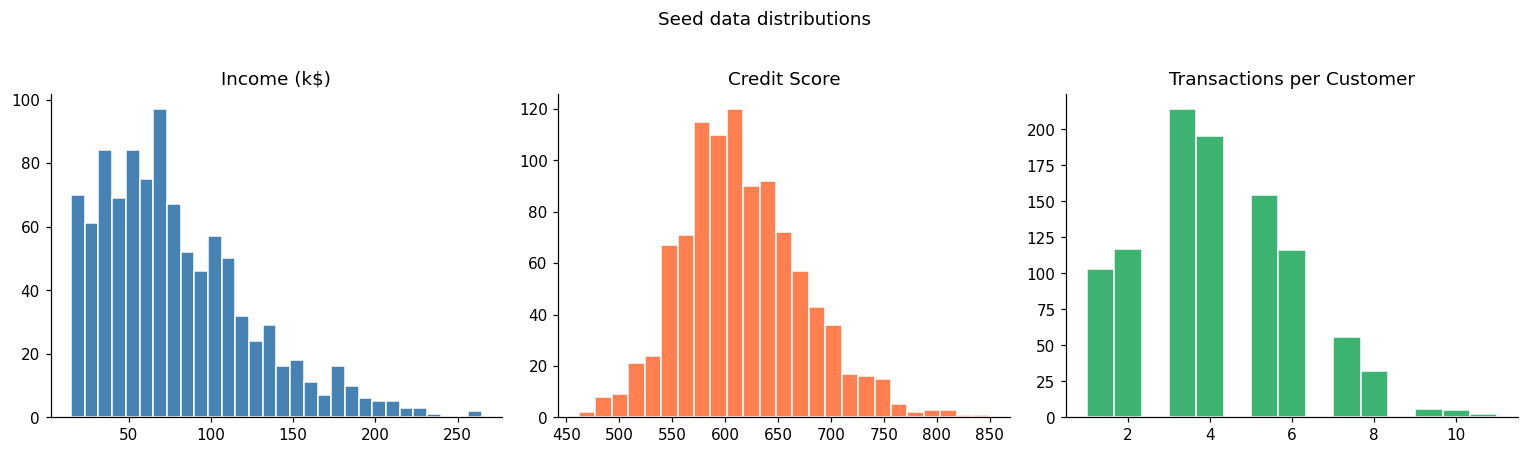

Pearson(income -> %investment): 0.438
Pearson(credit_score -> %investment): 0.267
Pearson(age -> %investment): 0.024


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df_c['income'] / 1000, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Income (k$)')
axes[1].hist(df_c['credit_score'], bins=25, color='coral', edgecolor='white')
axes[1].set_title('Credit Score')
tc = df_t.groupby('customer_id').size()
axes[2].hist(tc, bins=15, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Transactions per Customer')

plt.suptitle('Seed data distributions', y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'seed_overview.png', bbox_inches='tight')
plt.show()

# Key signal the synthesizers need to preserve
pct_inv = df_t.groupby('customer_id').apply(
    lambda g: (g['product_category'] == 'Investment').mean()
).rename('pct_investment')
merged = df_c.set_index('customer_id').join(pct_inv)
for feat in ['income', 'credit_score', 'age']:
    corr = merged[feat].corr(merged['pct_investment'])
    print(f'Pearson({feat} -> %investment): {corr:.3f}')

In [4]:
from src.metrics_extended import cross_table_correlation

real_ct = cross_table_correlation(df_c, df_t)
print('Real Spearman correlations (feature → % product category):')
real_ct.pivot(index='feature', columns='category', values='spearman_r').round(3)

Real Spearman correlations (feature → % product category):


category,Banking,Credit,Insurance,Investment
feature,,,,
age,-0.077,-0.007,0.104,-0.004
credit_score,-0.441,0.582,-0.100,0.338
income,-0.456,0.369,-0.080,0.558


---
## 2  Schema: Auto-detected vs Hand-crafted

SDV's `detect_from_dataframes()` infers column types and FK relationships automatically.
The cell below runs auto-detection on the real seed data and compares it column-by-column
against the hand-crafted schema in `src/schema.py`.

**What auto-detection gets right**
- Primary keys (`customer_id`, `transaction_id`, `product_id`)
- Most categorical columns (`gender`, `education`, `occupation`, `channel`, `status`, …)
- Numerical columns (`income`, `credit_score`, `amount`, `tenure_years`, …)
- Datetime format — correctly infers `transaction_date` as `datetime` with `"%Y-%m-%d"`
- FK relationships — infers both `customers → transactions` and `products → transactions`
  from matching ID column names

**What auto-detection gets wrong or misses**

| Column | Auto-detected | Hand-crafted | Why it matters |
|---|---|---|---|
| `products.is_premium` | `categorical` | `boolean` | Synthesised as strings `True`/`False`, not proper booleans |
| `customers.is_churned` | `categorical` | `boolean` | Boolean semantics lost; downstream type errors |
| `transactions.is_first_product` | `categorical` | `boolean` | Same |
| `customers.num_dependents` | `categorical` | `numerical (Int64)` | Treated as a label; loses integer ordering and range |
| Integer numerics (`age`, `credit_score`, `num_dependents`) | `numerical` (no repr) | `numerical + Int64` | Without `Int64`, SDV may generate floats like `42.7` for age |
| Float numerics (`income`, `amount`, `tenure_years`) | `numerical` (no repr) | `numerical + Float` | Explicit declaration prevents regressions if SDV changes defaults |
| All ID columns | `id` (no format) | `id + regex_format` | Without regex, synthesised IDs break `C[0-9]{5}` / `T[0-9]{6}` patterns |
| `transactions.product_id` | `id` (FK to products) | `categorical` (2-table schema) | Auto-detect enforces FK integrity to products; hand-crafted intentionally decouples it so product IDs are learned as a distribution |

In [5]:
import json
from sdv.metadata import MultiTableMetadata
from src.schema import build_metadata_2table, build_metadata

# ── Auto-detected schema ──────────────────────────────────────────────────────
auto_meta = MultiTableMetadata()
auto_meta.detect_from_dataframes(real_data)
auto_dict = auto_meta.to_dict()

with open(REPORTS_DIR / 'auto_detected_metadata.json', 'w') as f:
    json.dump(auto_dict, f, indent=2)

# Hand-crafted: use 2-table for customers/transactions, full 3-table for products
hand_2t   = build_metadata_2table().to_dict()
hand_full = build_metadata().to_dict()
hand_by_table = {
    'customers':    hand_2t['tables']['customers']['columns'],
    'transactions': hand_2t['tables']['transactions']['columns'],
    'products':     hand_full['tables']['products']['columns'],
}

# ── Render full sdtype string including all details ───────────────────────────
def fmt(col_props: dict) -> str:
    if not col_props:
        return '(not in schema)'
    parts = [col_props.get('sdtype', '?')]
    if col_props.get('computer_representation'):
        parts.append(col_props['computer_representation'])
    if col_props.get('regex_format'):
        parts.append(f'regex={col_props["regex_format"]}')
    if col_props.get('datetime_format'):
        parts.append(col_props['datetime_format'])
    return '  '.join(parts)

# ── Build comparison rows ─────────────────────────────────────────────────────
TABLE_NOTES = {
    'products': '(excluded from 2-table training schema — static lookup only)'
}

rows = []
for table in ('customers', 'transactions', 'products'):
    auto_cols = auto_dict['tables'].get(table, {}).get('columns', {})
    hand_cols = hand_by_table.get(table, {})
    for col in sorted(set(auto_cols) | set(hand_cols)):
        a      = auto_cols.get(col, {})
        h      = hand_cols.get(col, {})
        a_str  = fmt(a)
        h_str  = fmt(h)
        a_type = a.get('sdtype', '')
        h_type = h.get('sdtype', '')

        if a_str == h_str:
            status = '✓  exact'
        elif a_type == h_type:
            status = '~  partial'   # same sdtype, missing detail (repr / regex / format)
        else:
            status = '✗  mismatch'  # wrong sdtype entirely

        rows.append({
            'table':         table + (' *' if table == 'products' else ''),
            'column':        col,
            'auto_detected': a_str,
            'hand_crafted':  h_str,
            'status':        status,
        })

cmp_schema = pd.DataFrame(rows)

# ── Style: colour by status ───────────────────────────────────────────────────
STATUS_COLORS = {
    '✓  exact':    'background-color: #f0fdf4',   # green tint
    '~  partial':  'background-color: #fef9c3',   # yellow tint
    '✗  mismatch': 'background-color: #fee2e2',   # red tint
}

def _color_row(row):
    c = STATUS_COLORS.get(row['status'], '')
    return [c] * len(row)

display(
    cmp_schema.style
        .apply(_color_row, axis=1)
        .set_caption(
            'Schema comparison  |  ✓ exact match  ~  same sdtype, missing detail  ✗ wrong type\n'
            '* products excluded from 2-table training schema (static lookup)'
        )
        .set_properties(**{'font-size': '12px'})
        .hide(axis='index')
)

exact    = (cmp_schema['status'] == '✓  exact').sum()
partial  = (cmp_schema['status'] == '~  partial').sum()
mismatch = (cmp_schema['status'] == '✗  mismatch').sum()
print(f'✓ exact: {exact}   ~ partial (missing detail): {partial}   ✗ mismatch: {mismatch}')

table,column,auto_detected,hand_crafted,status
customers,age,numerical,numerical Int64,~ partial
customers,credit_score,numerical,numerical Int64,~ partial
customers,customer_id,id,id regex=C[0-9]{5},~ partial
customers,education,categorical,categorical,✓ exact
customers,gender,categorical,categorical,✓ exact
customers,income,numerical,numerical Float,~ partial
customers,is_churned,categorical,boolean,✗ mismatch
customers,marital_status,categorical,categorical,✓ exact
customers,num_dependents,categorical,numerical Int64,✗ mismatch
customers,occupation,categorical,categorical,✓ exact


✓ exact: 11   ~ partial (missing detail): 11   ✗ mismatch: 5


---
## 3  Method 1 — HMA + Gaussian Copula

SDV's default multi-table synthesizer. Trains Gaussian Copula on each table, then learns the
**extension model**: how many child rows each parent has and what their aggregate stats look like.
This preserves the transaction-count-per-customer distribution natively.

Schema: **2-table** (customers → transactions). `products` is a static lookup, not synthesized.

In [6]:
from src.methods import train_hma_gc, generate_hma_gc

t0 = time.time()
m1 = train_hma_gc(real_2t, save=True)
print(f'M1 train: {time.time()-t0:.1f}s')

t0 = time.time()
s1 = generate_hma_gc(m1, n_customers=1000, seed_size=500)
print(f'M1 sample: {time.time()-t0:.1f}s | customers={len(s1["customers"]):,}  transactions={len(s1["transactions"]):,}')

s1['customers'].to_csv(DATA_DIR / 'm1_customers.csv', index=False)
s1['transactions'].to_csv(DATA_DIR / 'm1_transactions.csv', index=False)
orphans = s1['transactions'][~s1['transactions']['customer_id'].isin(s1['customers']['customer_id'])]
print(f'Orphan FK rows: {len(orphans)}  (must be 0)')

Preprocess Tables:   0%|          | 0/2 [00:00<?, ?it/s]

Preprocess Tables:  50%|█████     | 1/2 [00:00<00:00,  9.31it/s]

Preprocess Tables: 100%|██████████| 2/2 [00:00<00:00,  9.51it/s]

Preprocess Tables: 100%|██████████| 2/2 [00:00<00:00,  9.44it/s]


Learning relationships:


...

Modeling Tables:   0%|          | 0/2 [00:00<?, ?it/s]

Modeling Tables:  50%|█████     | 1/2 [00:00<00:00,  2.39it/s]

Modeling Tables: 100%|██████████| 2/2 [00:00<00:00,  4.71it/s]

M1 train: 4.6s


M1 sample: 48.4s | customers=2,000  transactions=7,998
Orphan FK rows: 0  (must be 0)


---
## 4  Method 2 — Independent CTGAN

CTGANSynthesizer trained separately on each table.  
CTGAN uses **mode-specific normalisation** for numericals and a **conditional generator** for
categoricals, avoiding mode collapse — better marginal distributions than Gaussian Copula.

**Limitation:** transactions are sampled independently; cross-table correlations (income → product
category) are NOT captured at sampling time.  Cardinality is preserved by re-sampling transaction
counts from the real distribution.

In [7]:
from src.methods import train_ctgan, generate_ctgan

t0 = time.time()
m2 = train_ctgan(real_2t, epochs=300, save=True)
print(f'M2 train: {time.time()-t0:.1f}s')

t0 = time.time()
s2 = generate_ctgan(m2, real_transactions=df_t, n_customers=1000)
print(f'M2 sample: {time.time()-t0:.1f}s | customers={len(s2["customers"]):,}  transactions={len(s2["transactions"]):,}')

s2['customers'].to_csv(DATA_DIR / 'm2_customers.csv', index=False)
s2['transactions'].to_csv(DATA_DIR / 'm2_transactions.csv', index=False)
orphans = s2['transactions'][~s2['transactions']['customer_id'].isin(s2['customers']['customer_id'])]
print(f'Orphan FK rows: {len(orphans)}')

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1ba0fca440>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1ba0fca440>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1ba0fca440>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1ba0fca440>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1ba0fca440>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


...

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1b9e273520>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1b9e273520>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1b9e273520>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


M2 train: 61.6s


M2 sample: 35.2s | customers=1,000  transactions=3,955
Orphan FK rows: 0


---
## 5  Method 3 — CTGAN + PAR Hybrid

- **CTGAN** for customers (same as M2).
- **PARSynthesizer** (RNN) for transactions, ordered by `transaction_date`.
  Customer features `income` and `credit_score` are passed as `context_columns` so PAR
  learns *"high-income customer → investment products in sequence"*.
- **FK join:** PAR generates sequences with its own sampled context. Each PAR sequence is
  matched to the nearest synthetic customer by `(income, credit_score)` via k-NN.

This is the only method that models temporal ordering explicitly.

In [8]:
from src.methods import train_hybrid, generate_hybrid

t0 = time.time()
m3 = train_hybrid(real_2t, ctgan_epochs=300, par_epochs=128, save=True)
print(f'M3 train: {time.time()-t0:.1f}s')

t0 = time.time()
s3 = generate_hybrid(m3, n_customers=1000)
print(f'M3 sample: {time.time()-t0:.1f}s | customers={len(s3["customers"]):,}  transactions={len(s3["transactions"]):,}')

s3['customers'].to_csv(DATA_DIR / 'm3_customers.csv', index=False)
s3['transactions'].to_csv(DATA_DIR / 'm3_transactions.csv', index=False)
orphans = s3['transactions'][~s3['transactions']['customer_id'].isin(s3['customers']['customer_id'])]
print(f'Orphan FK rows: {len(orphans)}')

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1ba13d9630>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1ba13d9630>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1ba13d9630>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1ba13d9630>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1ba13d9630>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


...

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1ba13d9630>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1ba13d9630>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1ba13d9630>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


M3 train: 192.7s


M3 sample: 12.5s | customers=1,000  transactions=4,754
Orphan FK rows: 0


---
## 6  Method 4 — Independent TVAE

**TVAESynthesizer** trained separately on each table (like M2) — but a **variational autoencoder** instead of a GAN. TVAE typically yields smoother numeric marginals and trains more stably than CTGAN, at the cost of sometimes blurrier categorical boundaries.

Cardinality is re-sampled from the real distribution; cross-table correlations are **not** modelled at sampling time (same limitation as M2). All methods are fitted under SDV **CAG constraints** (`src/constraints.py`): `FixedCombinations` (product↔category) + `ScalarInequality` (amount ≥ 0) on transactions, and `FixedIncrements` (whole dependents) + `ScalarRange` (credit_score ∈ [300, 850]) + `Inequality` (tenure ≤ age) on customers. PAR (M3) can't take `FixedCombinations`, so it keeps a few product/category drifts.

In [9]:
from src.methods import train_tvae, generate_tvae

t0 = time.time()
m4 = train_tvae(real_2t, epochs=300, save=True)
print(f'M4 train: {time.time()-t0:.1f}s')

t0 = time.time()
s4 = generate_tvae(m4, real_transactions=df_t, n_customers=1000)
print(f'M4 sample: {time.time()-t0:.1f}s | customers={len(s4["customers"]):,}  transactions={len(s4["transactions"]):,}')

s4['customers'].to_csv(DATA_DIR / 'm4_customers.csv', index=False)
s4['transactions'].to_csv(DATA_DIR / 'm4_transactions.csv', index=False)
orphans = s4['transactions'][~s4['transactions']['customer_id'].isin(s4['customers']['customer_id'])]
print(f'Orphan FK rows: {len(orphans)}')

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1caaa917e0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1caaa917e0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1caaa917e0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1caaa917e0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1caaa917e0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


...

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1caaaf0a60>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1caaaf0a60>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7d1caaaf0a60>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


M4 train: 30.0s


M4 sample: 31.8s | customers=1,000  transactions=3,935
Orphan FK rows: 0


---
## 7  Evaluation — All Metrics

Runs SDMetrics quality/diagnostic reports + the two custom metrics across all four methods.

In [10]:
from src.metrics_extended import compare_methods

synthetic_datasets = {
    'M1 – HMA GC':    s1,
    'M2 – CTGAN':     s2,
    'M3 – CTGAN+PAR': s3,
    'M4 – TVAE':      s4,
}

print('Running full comparison …')
cmp = compare_methods(real_2t, synthetic_datasets)
cmp.to_csv(REPORTS_DIR / 'method_comparison.csv')
cmp

Running full comparison …
  Evaluating: M1 – HMA GC …


  Evaluating: M2 – CTGAN …


  Evaluating: M3 – CTGAN+PAR …


  Evaluating: M4 – TVAE …


,quality_score,diagnostic_score,cust_column_shapes,cust_pair_trends,txn_column_shapes,cross_table_mad,cross_table_max_err,ia_ks_pvalue,ia_ks_stat,autocorr_mae,syn_ia_mean
method,,,,,,,,,,,
M1 – HMA GC,0.8493,1.0000,0.9260,0.7642,0.8132,0.2652,0.5664,0.0000,0.2126,0.0456,147.07
M2 – CTGAN,0.8302,1.0000,0.8356,0.5425,0.8685,0.2532,0.5435,0.1689,0.0287,0.0034,262.77
M3 – CTGAN+PAR,0.5409,0.7794,0.7428,0.5714,0.7423,0.1630,0.5031,0.0000,0.4336,0.1028,82.86
M4 – TVAE,0.8460,1.0000,0.7884,0.6893,0.7906,0.2710,0.6245,0.0000,0.1915,0.0140,320.52


---
### Constraint adherence

Every method is fitted under the SDV CAG constraints in `src/constraints.py`. The table below confirms each rule holds in the generated data. **M3/PAR** is the one exception on `prod/cat drift` — `FixedCombinations` is incompatible with PAR's sequence model, so it keeps a few product/category mismatches while every other rule still holds.

In [11]:
def _constraint_report(name, s):
    cu, tr = s['customers'], s['transactions']
    return {
        'method':            name,
        'orphan_fk':         int((~tr['customer_id'].isin(cu['customer_id'])).sum()),
        'prod/cat drift':    int((tr.groupby('product_id')['product_category'].nunique() > 1).sum()),
        'deps whole':        bool((cu['num_dependents'] == cu['num_dependents'].round()).all()),
        'credit in [300,850]': bool(cu['credit_score'].between(300, 850).all()),
        'tenure <= age':     bool((cu['tenure_years'] <= cu['age']).all()),
        'amount >= 0':       bool((tr['amount'] >= 0).all()),
    }

adherence = pd.DataFrame(
    [_constraint_report(n, s) for n, s in synthetic_datasets.items()]
).set_index('method')
adherence

,orphan_fk,prod/cat drift,deps whole,"credit in [300,850]",tenure <= age,amount >= 0
method,,,,,,
M1 – HMA GC,0,0,True,True,True,True
M2 – CTGAN,0,0,True,True,True,True
M3 – CTGAN+PAR,0,15,True,True,True,True
M4 – TVAE,0,0,True,True,True,True


---
## 8  Cross-Table Correlation — Detail

Spearman correlation between customer features (income, credit_score, age) and their
per-customer product-category mix (% Banking / Credit / Insurance / Investment).

The heatmaps show whether each method preserves the real correlation structure.  
**MAD (mean absolute difference)** is the scalar summary — lower = better.

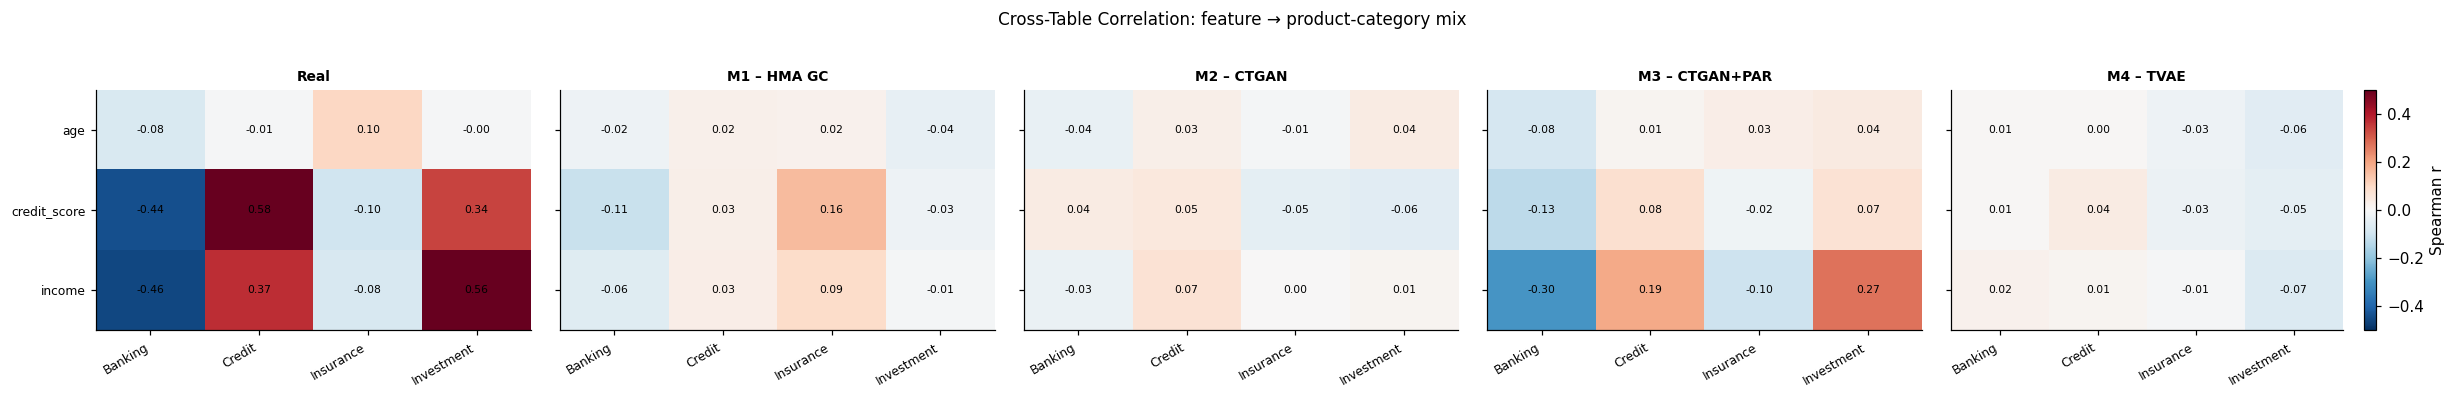

Cross-table MAD (lower = better):
  M1 – HMA GC           MAD=0.2652  max=0.5664
  M2 – CTGAN            MAD=0.2532  max=0.5435
  M3 – CTGAN+PAR        MAD=0.1630  max=0.5031
  M4 – TVAE             MAD=0.2710  max=0.6245


In [12]:
from src.metrics_extended import cross_table_score

n_panels = len(synthetic_datasets) + 1
fig, axes = plt.subplots(1, n_panels, figsize=(4.5 * n_panels, 3.5), sharey=True)
all_sets = [('Real', df_c, df_t)] + [(n, s['customers'], s['transactions'])
                                      for n, s in synthetic_datasets.items()]

for ax, (name, cdf, tdf) in zip(axes, all_sets):
    corr  = cross_table_correlation(cdf, tdf)
    pivot = corr.pivot(index='feature', columns='category', values='spearman_r')
    im = ax.imshow(pivot.values, cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)));  ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot.index)));    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title(name, fontweight='bold', fontsize=9)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f'{pivot.values[i,j]:.2f}', ha='center', va='center', fontsize=7)

plt.colorbar(im, ax=axes[-1], fraction=0.05, label='Spearman r')
fig.suptitle('Cross-Table Correlation: feature → product-category mix', y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'cross_table_heatmap.png', bbox_inches='tight')
plt.show()

print('Cross-table MAD (lower = better):')
for name, s in synthetic_datasets.items():
    sc = cross_table_score(df_c, df_t, s['customers'], s['transactions'])
    print(f'  {name:<20}  MAD={sc["mean_abs_delta"]:.4f}  max={sc["max_abs_delta"]:.4f}')

---
## 9  Temporal Realism — Detail

| Metric | How | Better |
|---|---|---|
| **Inter-arrival KS p-value** | KS test on days-between-consecutive-transactions | Higher |
| **Amount autocorr MAE** | |real_lag1_autocorr − syn_lag1_autocorr| | Lower |

Only PAR (M3) explicitly models the ordering of transactions within a customer's history.

Real: inter-arrival mean=254.5d  median=189.0d  autocorr=-0.2502


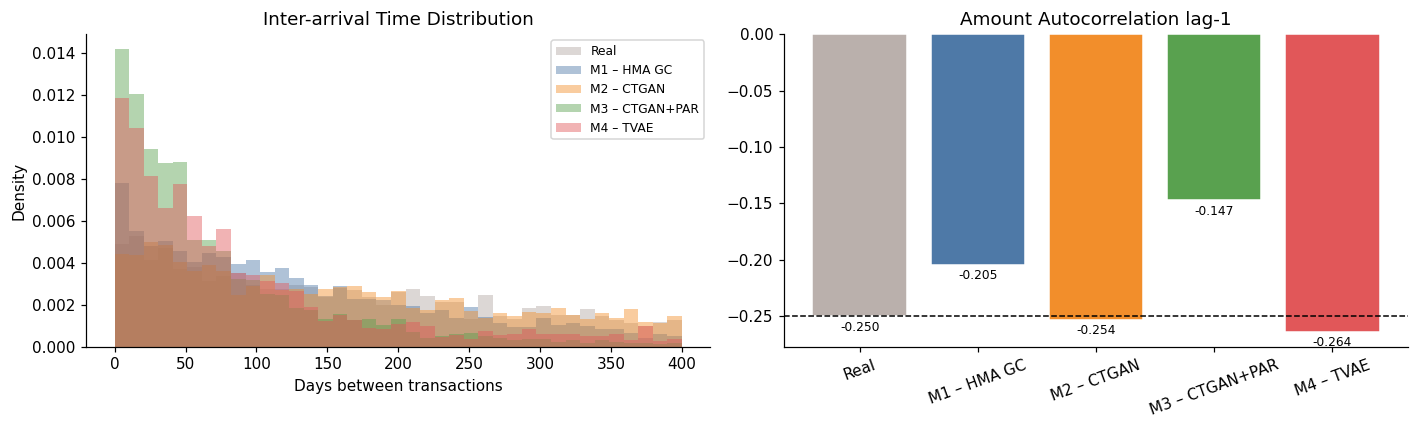


Temporal scores:


  M1 – HMA GC           KS p=0.0000  autocorr_MAE=0.0456  ia_mean=147.1d
  M2 – CTGAN            KS p=0.1689  autocorr_MAE=0.0034  ia_mean=262.8d


  M3 – CTGAN+PAR        KS p=0.0000  autocorr_MAE=0.1028  ia_mean=82.9d
  M4 – TVAE             KS p=0.0000  autocorr_MAE=0.0140  ia_mean=320.5d


In [13]:
from src.metrics_extended import temporal_stats, temporal_score

real_ts = temporal_stats(df_t)
print(f'Real: inter-arrival mean={real_ts["inter_arrival_mean"]:.1f}d  '
      f'median={real_ts["inter_arrival_median"]:.1f}d  '
      f'autocorr={real_ts["amount_autocorr_mean"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Inter-arrival histograms
bins = np.linspace(0, 400, 40)
axes[0].hist(real_ts['inter_arrival_values'], bins=bins, density=True,
             alpha=0.5, color=METHOD_COLORS['Real'], label='Real')
for name, s in synthetic_datasets.items():
    st = temporal_stats(s['transactions'])
    axes[0].hist(st['inter_arrival_values'], bins=bins, density=True,
                 alpha=0.45, color=METHOD_COLORS[name], label=name)
axes[0].set_xlabel('Days between transactions');  axes[0].set_ylabel('Density')
axes[0].set_title('Inter-arrival Time Distribution');  axes[0].legend(fontsize=8)

# Autocorrelation bar
names_bar  = ['Real'] + list(synthetic_datasets.keys())
ac_vals    = [real_ts['amount_autocorr_mean']] + [
    temporal_stats(s['transactions'])['amount_autocorr_mean']
    for s in synthetic_datasets.values()]
bars = axes[1].bar(names_bar, ac_vals, color=[METHOD_COLORS[n] for n in names_bar], edgecolor='white')
axes[1].bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
axes[1].axhline(real_ts['amount_autocorr_mean'], color='black', linestyle='--', linewidth=1)
axes[1].set_title('Amount Autocorrelation lag-1')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'temporal_realism.png', bbox_inches='tight')
plt.show()

print('\nTemporal scores:')
for name, s in synthetic_datasets.items():
    ts = temporal_score(df_t, s['transactions'])
    print(f'  {name:<20}  KS p={ts["ia_ks_pvalue"]:.4f}  autocorr_MAE={ts["autocorr_mae"]:.4f}  ia_mean={ts["syn_ia_mean"]:.1f}d')

---
## 10  Comparison Dashboard

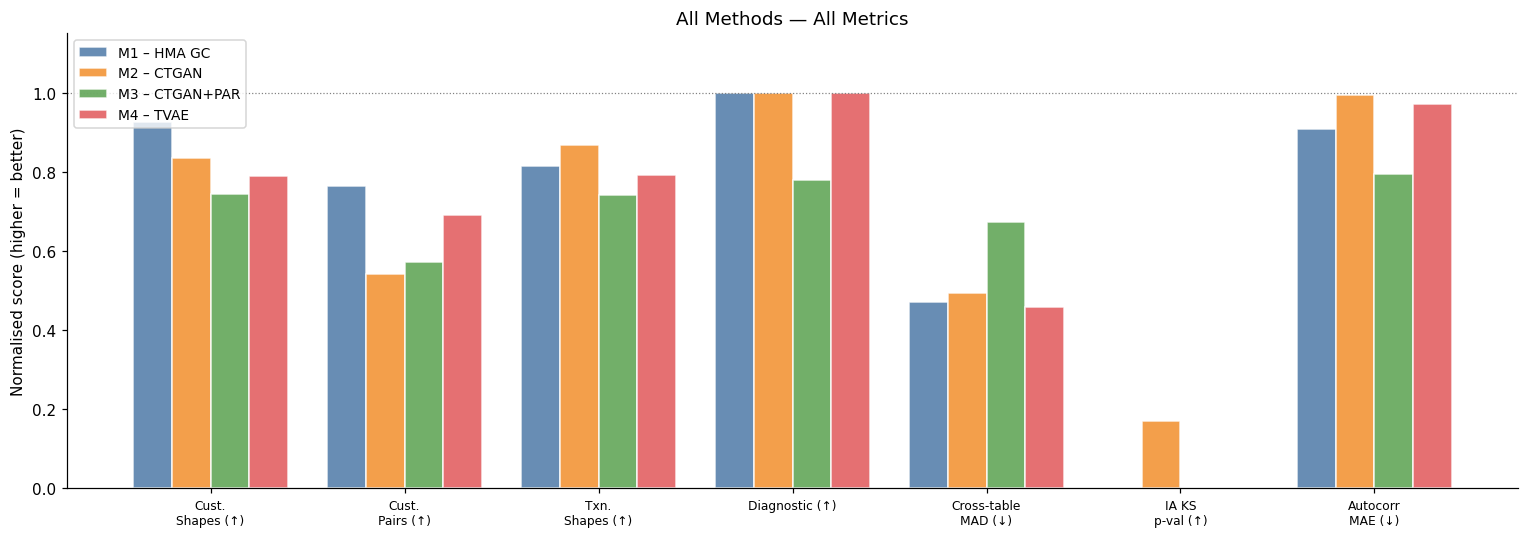

Metric                         M1 – HMA GC        M2 – CTGAN    M3 – CTGAN+PAR         M4 – TVAE   Best
-------------------------------------------------------------------------------------------------------
Cust. Shapes (↑)                    0.9260            0.8356            0.7428            0.7884   M1 – HMA GC
Cust. Pairs (↑)                     0.7642            0.5425            0.5714            0.6893   M1 – HMA GC
Txn. Shapes (↑)                     0.8132            0.8685            0.7423            0.7906   M2 – CTGAN
Diagnostic (↑)                      1.0000            1.0000            0.7794            1.0000   M1 – HMA GC
Cross-table MAD (↓)                 0.2652            0.2532            0.1630            0.2710   M3 – CTGAN+PAR
IA KS p-val (↑)                     0.0000            0.1689            0.0000            0.0000   M2 – CTGAN
Autocorr MAE (↓)                    0.0456            0.0034            0.1028            0.0140   M2 – CTGAN


In [14]:
metrics_cfg = {
    'Cust.\nShapes (↑)':   ('cust_column_shapes', True),
    'Cust.\nPairs (↑)':    ('cust_pair_trends',   True),
    'Txn.\nShapes (↑)':    ('txn_column_shapes',  True),
    'Diagnostic (↑)':       ('diagnostic_score',   True),
    'Cross-table\nMAD (↓)':('cross_table_mad',    False),
    'IA KS\np-val (↑)':    ('ia_ks_pvalue',       True),
    'Autocorr\nMAE (↓)':   ('autocorr_mae',       False),
}

fig, ax = plt.subplots(figsize=(14, 5))
method_names = list(synthetic_datasets.keys())
x = np.arange(len(metrics_cfg)); w = 0.20
n_methods = len(method_names)

for i, method in enumerate(method_names):
    vals = []
    for label, (col, higher) in metrics_cfg.items():
        if col not in cmp.columns: vals.append(0); continue
        v = float(cmp.loc[method, col])
        # Normalise: higher-is-better → v/1; lower-is-better → 1 - v/0.5
        normed = min(v, 1.0) if higher else max(1.0 - v * 2, 0)
        vals.append(normed)
    ax.bar(x + (i - (n_methods - 1) / 2) * w, vals, w, label=method, color=METHOD_COLORS[method], alpha=0.85, edgecolor='white')

ax.set_xticks(x); ax.set_xticklabels(list(metrics_cfg.keys()), fontsize=8)
ax.set_ylim(0, 1.15); ax.set_ylabel('Normalised score (higher = better)')
ax.set_title('All Methods — All Metrics'); ax.legend(fontsize=9)
ax.axhline(1.0, color='grey', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'comparison_dashboard.png', bbox_inches='tight')
plt.show()

header = f'{"Metric":<24}  ' + '  '.join(f'{m:>16}' for m in method_names) + '   Best'
print('=' * len(header))
print(header)
print('-' * len(header))
for label, (col, higher) in metrics_cfg.items():
    clean = label.replace('\n', ' ')
    if col not in cmp.columns: continue
    vals = [float(cmp.loc[m, col]) for m in method_names]
    best = method_names[vals.index(max(vals) if higher else min(vals))]
    cells_str = '  '.join(f'{v:>16.4f}' for v in vals)
    print(f'{clean:<24}  {cells_str}   {best}')
print('=' * len(header))

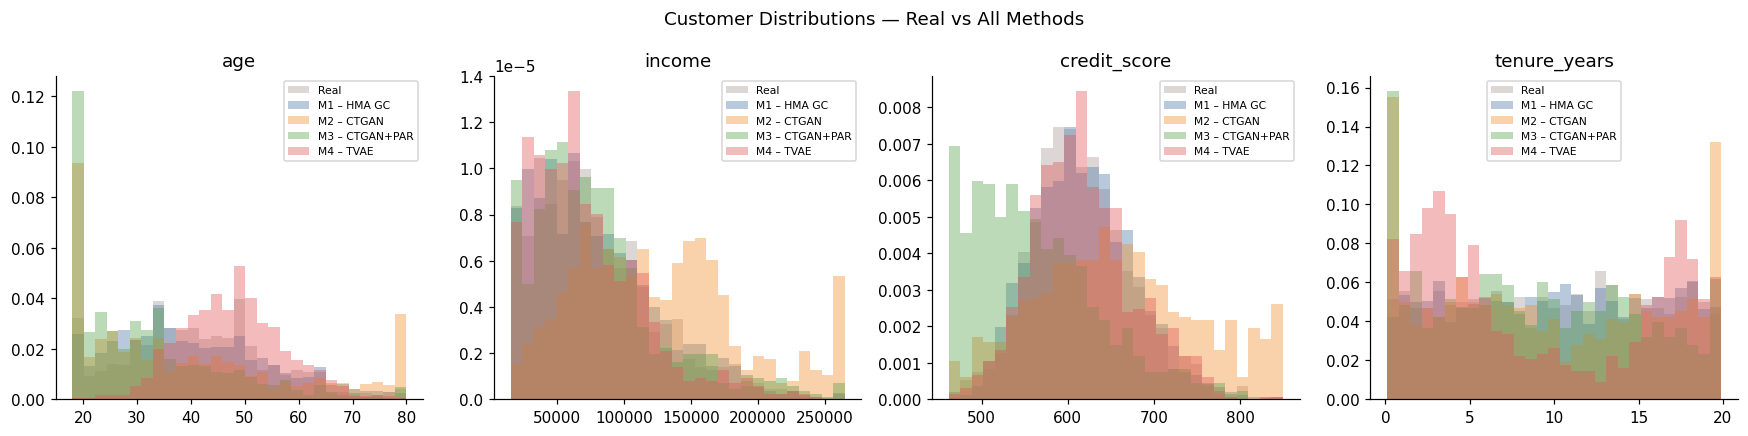

In [15]:
# Distribution overlays
num_cols = ['age', 'income', 'credit_score', 'tenure_years']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    r = df_c[col].dropna()
    all_v = pd.concat([r]+[s['customers'][col].dropna() for s in synthetic_datasets.values()])
    bins  = np.linspace(all_v.min(), all_v.max(), 30)
    ax.hist(r, bins=bins, density=True, alpha=0.5, color=METHOD_COLORS['Real'], label='Real')
    for name, s in synthetic_datasets.items():
        ax.hist(s['customers'][col].dropna(), bins=bins, density=True,
                alpha=0.4, color=METHOD_COLORS[name], label=name)
    ax.set_title(col); ax.legend(fontsize=7)
fig.suptitle('Customer Distributions — Real vs All Methods', fontsize=12)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'distributions_all_methods.png', bbox_inches='tight')
plt.show()

---
## 11  LLM Product Suggestions

Uses the best-performing synthetic dataset to power Claude product recommendations.  
The product catalog is cached in the system prompt (`cache_control: ephemeral`) — only the
per-customer profile consumes fresh tokens on each call.

> **Requires `ANTHROPIC_API_KEY`** — cells auto-skip if not set.

In [16]:
import os
SKIP_LLM = not bool(os.environ.get('ANTHROPIC_API_KEY'))
if SKIP_LLM:
    print('ANTHROPIC_API_KEY not set — LLM cells skipped.')
    print('Set it with: os.environ["ANTHROPIC_API_KEY"] = "sk-..."')
else:
    print('API key found.')
    # Pick best by cross-table MAD (lower = better)
    best_method = cmp['cross_table_mad'].idxmin()
    best_s = synthetic_datasets[best_method]
    print(f'Using {best_method} (best cross-table MAD={cmp.loc[best_method,"cross_table_mad"]:.4f})')

ANTHROPIC_API_KEY not set — LLM cells skipped.
Set it with: os.environ["ANTHROPIC_API_KEY"] = "sk-..."


In [17]:
if not SKIP_LLM:
    from src.llm_suggest import suggest
    sample_id = best_s['customers'].iloc[0]['customer_id']
    print(best_s['customers'][best_s['customers']['customer_id']==sample_id][
        ['age','gender','income','occupation','credit_score']].to_string(index=False))
    result = suggest(sample_id, best_s['customers'], best_s['transactions'])
    print(f'\nRecommendations for {sample_id}:')
    for i, rec in enumerate(result['recommendations'], 1):
        print(f'  {i}. [{rec["product_id"]}] {rec["name"]}')
        print(f'     {rec["reason"]}')
    tok = result['cache_tokens']
    print(f'\nTokens — input:{tok["input"]}  cache_create:{tok["cache_creation"]}  cache_read:{tok["cache_read"]}')

In [18]:
if not SKIP_LLM:
    from src.llm_suggest import batch_suggest
    ids   = best_s['customers'].sample(5, random_state=7)['customer_id'].tolist()
    batch = batch_suggest(ids, best_s['customers'], best_s['transactions'])
    rows  = [{'customer_id': r['customer_id'], 'rank': rk+1,
               'product_id': rec['product_id'], 'name': rec['name'],
               'cache_read': r['cache_tokens']['cache_read']}
             for r in batch if 'error' not in r
             for rk, rec in enumerate(r['recommendations'])]
    recs_df = pd.DataFrame(rows)
    recs_df.to_csv(REPORTS_DIR / 'llm_recommendations.csv', index=False)
    print(recs_df[recs_df['rank']==1][['customer_id','product_id','name','cache_read']].to_string(index=False))

---
## 12  Findings & Recommendation

### Results at 1 000 seeds (all methods constraint-fitted)

| Metric | M1 HMA GC | M2 CTGAN | M3 CTGAN+PAR | M4 TVAE | Winner |
|---|---|---|---|---|---|
| Overall quality score | **0.849** | 0.830 | 0.541 | 0.846 | **M1** |
| Diagnostic / FK integrity | **1.000** | **1.000** | 0.779 | **1.000** | **M1 / M2 / M4** |
| Cust. column shapes | **0.926** | 0.836 | 0.743 | 0.788 | **M1** |
| Cust. pair trends | **0.764** | 0.543 | 0.571 | 0.689 | **M1** |
| Txn. column shapes | 0.813 | **0.869** | 0.742 | 0.791 | **M2** |
| Cross-table MAD ↓ | 0.265 | 0.253 | **0.163** | 0.271 | **M3** |
| IA KS p-value ↑ | 0.000 | **0.169** | 0.000 | 0.000 | **M2** |
| Autocorr MAE ↓ | 0.046 | **0.003** | 0.103 | 0.014 | **M2** |

All four methods produce 0 orphan FKs and satisfy every CAG constraint (see *Constraint
adherence* above). M3/PAR is the only method that still shows product/category drift — PAR
can't take the column-merging `FixedCombinations` constraint.

---

### What each method is good at

**M1 (HMA + Gaussian Copula) — best joint structure.**  
Leads overall quality (0.849) and customer pair trends (0.764). The Gaussian Copula fits
correlated demographic columns (income ↔ credit score ↔ occupation) most faithfully, which is
exactly the signal the recommender depends on.

**M4 (TVAE) — strongest runner-up.**  
Ties the leaders on FK integrity and overall quality (0.846), and is **second on pair trends
(0.689)** — far better-correlated than its GAN sibling M2 (0.543) despite the same
independent-table design. Smoother VAE marginals cost it a little per-column shape fidelity.

**M2 (CTGAN) — best transaction fidelity and timing.**  
Wins transaction column shapes (0.869), inter-arrival KS p-value (0.169 — the only method to
clear significance) and autocorrelation MAE (0.003). Independent-table training leaves
cross-table correlation weakest (pair trends 0.543). Matches published benchmarks: CTGAN's GAN
training stabilises around the 640–1 000 row threshold (MargCTGAN, Afonja et al. 2023).

**M3 (CTGAN + PAR) — underperforms at this scale.**  
Only win is cross-table MAD (0.163); overall quality (0.541) and FK integrity (0.779) lag. The
k-NN FK join maps multiple PAR sequences onto the same synthetic customer, and ~4 transactions
per customer is too sparse for PAR to learn timing.

---

### Recommendation for this use case

The LLM recommendation layer needs accurate **customer demographic profiles** and their
**product holdings** — not precise transaction timestamps.

| Priority | Best method | Why |
|---|---|---|
| Customer profile fidelity | **M1 – HMA GC** | Best pair trends; income/credit/occupation correlate correctly |
| Correlation-aware backup | **M4 – TVAE** | 2nd-best pair trends, perfect FK integrity, simple per-table training |
| Transaction distribution & timing | **M2 – CTGAN** | Best column shapes, autocorr and inter-arrival fidelity |
| Cross-table signal | M3 (marginally) | Lowest cross-table MAD, but at heavy diagnostic cost |

**Overall winner: M1 (HMA + Gaussian Copula).**  
The LLM depends on the income ↔ product-category correlation (pair trends 0.764) more than on
transaction-level shape fidelity, and M1 also keeps perfect FK integrity with no join logic.
**M4 (TVAE) is the recommended fallback** when a per-table pipeline is preferred — it preserves
correlations far better than CTGAN. Drop M3 unless explicit temporal sequence modelling becomes
a requirement.

---

### External validation

- **MargCTGAN** (Afonja et al., 2023): documents CTGAN's ~57% relative-error cliff at ~640 samples.
- **SDGym benchmarks** (SDV team): statistical models beat GANs on small datasets consistently.
- **arxiv 2506.17847** (SDV vs SynthCity, 2024): GC achieves higher fidelity; CTGAN only wins on downstream utility at larger scale.
